## **Baseline de Machine Learning e Combinação de Datasets**

**Fase Inicial do Trabalho Prático**

Notebook que implementa a geração de múltiplas combinações de datasets e estabelece um modelo base para classificação de texto:

1. **Geração de Combinações** — Criação de todas as combinações possíveis de datasets.
2. **Modelo Base** — Logistic Regression + TF-IDF.
3. **Avaliação** — Avaliação com Dataset do Professor.
4. **Distribuição** - Vizualização dos melhores modelos.

### **1. Imports e Configuração**

In [ ]:
import pandas as pd
import numpy as np
import os
import itertools
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

### **2. Definição de Categorias e Geração de Combinações**
Aqui definimos os ficheiros disponíveis por categoria (Humanos, OpenAI, Google, etc.) e usamos o Produto Cartesiano (`itertools.product`) para gerar todas as misturas possíveis de datasets diretamente na memória, sem necessidade de guardar vários ficheiros físicos.

In [ ]:
import pandas as pd
import itertools

# 1. Definir os ficheiros organizados por categorias
piscina_de_dados = {
    "Human": [
        "../data/human.csv"
    ],
    "OpenAI": [
        "../data/gpt-4o.csv",
        "../data/gpt-3.5-turbo.csv",
        "../data/gpt-4o-mini.csv",
        "../data/gpt-5o-mini.csv"
    ],
    "Google": [
        "../data/gemini-pro.csv",
        "../data/gemini-flash.csv",
        "../data/gemma1.csv",
        "../data/gemma2.csv",
        "../data/gemma3.csv"
    ],
    "Anthropic": [
        "../data/opus4.6.csv",
        "../data/sonnet4.6.csv",
        "../data/haiku4.5.csv"
    ],
    "Meta": [
        "../data/llama3.csv",
        "../data/llama3.1.csv",
        "../data/llama3.2.csv"
    ]
}

colunas_base = ['Text', 'Label']

lista = [] 
todas_combinacoes = list(itertools.product(*list(piscina_de_dados.values())))

print(f"A gerar {len(todas_combinacoes)} combinações diretamente na memória...")

for i, combinacao_atual in enumerate(todas_combinacoes, 1):
    lista_dataframes = []
    for ficheiro in combinacao_atual:
        try:
            df = pd.read_csv(ficheiro, sep=';').head(500)
            if set(colunas_base).issubset(df.columns):
                lista_dataframes.append(df[colunas_base].copy())
        except: 
            pass
            
    if lista_dataframes:
        dataset_combinado = pd.concat(lista_dataframes, ignore_index=True)
        dataset_combinado = dataset_combinado.sample(frac=1, random_state=42).reset_index(drop=True)
        dataset_combinado['ID'] = [f"C{i}-{j+1}" for j in range(len(dataset_combinado))]
        
        lista.append({
            'comb_id': i, 
            'dataframe': dataset_combinado, 
            'ficheiros_usados': combinacao_atual
        })

print("✅ Combinações geradas!")

A gerar 180 combinações diretamente na memória...
✅ Combinações geradas!


### **3. Avaliação das Combinações com K-Fold Cross-Validation**
Para garantir que os resultados não são fruto do acaso, avaliamos cada combinação gerada usando **Stratified K-Fold (K=5)**. Em cada "fold", o `TfidfVectorizer` é ajustado apenas aos dados de treino para evitar fuga de dados (*data leakage*).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Carregar o dataset de teste apenas UMA vez (muito mais eficiente)
ficheiro_teste = r"..\data\raw\dataset-exemplos.csv"
df_teste = pd.read_csv(ficheiro_teste, sep=';')
X_teste_raw = df_teste['Text']
y_teste = df_teste['Label']

resultados = []

print(f"🚀 A treinar e testar {len(lista)} combinações. Aguarda um momento...\n")

# 2. Iterar sobre cada combinação
for comb in lista:
    df = comb['dataframe'] 
    X_train_raw = df['Text']
    y_train = df['Label']
    
    # Vetorização (Ajustada apenas ao treino para não haver data leakage)
    vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
    X_train = vectorizer.fit_transform(X_train_raw)
    X_teste = vectorizer.transform(X_teste_raw)
    
    # Treino
    modelo = LogisticRegression(max_iter=5000, random_state=42)
    modelo.fit(X_train, y_train)
    
    # Previsão e Métricas
    y_pred = modelo.predict(X_teste)
    acc = accuracy_score(y_teste, y_pred)
    
    # Guardamos as labels do modelo e a matriz de confusão para desenhar depois
    cm = confusion_matrix(y_teste, y_pred, labels=modelo.classes_)
    
    # Limpar os nomes dos ficheiros para a tabela ficar legível (tira os ../data/)
    nomes_ficheiros = " + ".join([f.split('\\')[-1].split('/')[-1] for f in comb['ficheiros_usados']])
    
    resultados.append({
        'ID da Combinação': comb['comb_id'],
        'Accuracy (Teste)': acc,
        'Ficheiros Usados': nomes_ficheiros,
        'cm': cm,                  # Guardamos a matriz escondida aqui
        'classes': modelo.classes_ # Guardamos as classes escondidas aqui
    })

# 3. Criar DataFrame com os resultados e ordenar do melhor para o pior
df_resultados = pd.DataFrame(resultados)
df_ranking = df_resultados.sort_values(by='Accuracy (Teste)', ascending=False).reset_index(drop=True)

# Mostrar a Tabela Bonita (ocultamos as colunas técnicas 'cm' e 'classes')
print("🏆 RANKING 🏆")
display(df_ranking[['ID da Combinação', 'Accuracy (Teste)', 'Ficheiros Usados']])

🚀 A treinar e testar 180 combinações. Aguarda um momento...

🏆 RANKING 🏆


,ID da Combinação,Accuracy (Teste),Ficheiros Usados
0,26,0.568,human.csv + gpt-4o.csv + gemma1.csv + haiku4.5...
1,35,0.560,human.csv + gpt-4o.csv + gemma2.csv + haiku4.5...
2,44,0.560,human.csv + gpt-4o.csv + gemma3.csv + haiku4.5...
3,89,0.560,human.csv + gpt-3.5-turbo.csv + gemma3.csv + h...
4,88,0.560,human.csv + gpt-3.5-turbo.csv + gemma3.csv + h...
...,...,...,...
175,138,0.464,human.csv + gpt-5o-mini.csv + gemini-pro.csv +...
176,155,0.464,human.csv + gpt-5o-mini.csv + gemma1.csv + opu...
177,55,0.448,human.csv + gpt-3.5-turbo.csv + gemini-flash.c...
178,60,0.448,human.csv + gpt-3.5-turbo.csv + gemini-flash.c...


📊 A analisar a presença de ficheiros CSV nos 10 melhores modelos...



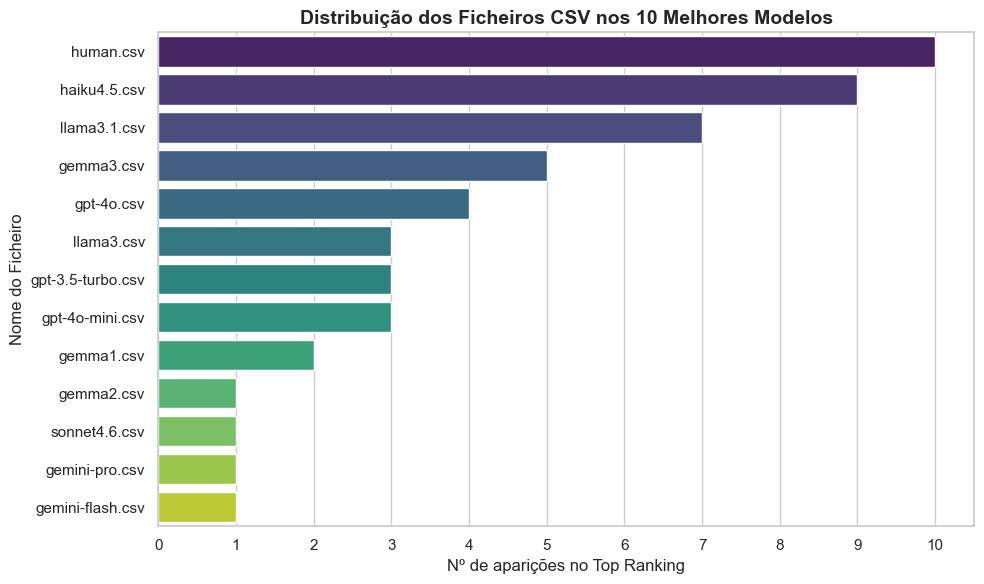

In [ ]:
from collections import Counter

# 1. Define quantos modelos do topo queres analisar (ex: os 10 melhores)
TOP_K = 10
print(f"📊 A analisar a presença de ficheiros CSV nos {TOP_K} melhores modelos...\n")

# 2. Isolar as strings de ficheiros dos melhores modelos
melhores_ficheiros_str = df_ranking.head(TOP_K)['Ficheiros Usados']

# 3. Separar as strings e contar os ficheiros
lista_todos_ficheiros = []
for f_str in melhores_ficheiros_str:
    # O split separa a string pelo " + " e remove espaços extra
    ficheiros_separados = [f.strip() for f in f_str.split('+')]
    lista_todos_ficheiros.extend(ficheiros_separados)

# O Counter faz a contagem automática de quantas vezes cada ficheiro aparece
contagem = Counter(lista_todos_ficheiros)

# 4. Transformar num DataFrame para plotar facilmente
df_distribuicao = pd.DataFrame.from_dict(contagem, orient='index', columns=['Presença']).reset_index()
df_distribuicao = df_distribuicao.rename(columns={'index': 'Ficheiro CSV'})
df_distribuicao = df_distribuicao.sort_values(by='Presença', ascending=False)

# 5. Desenhar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=df_distribuicao, 
            x='Presença', 
            y='Ficheiro CSV', 
            hue='Ficheiro CSV', 
            palette='viridis', 
            legend=False)

plt.title(f'Distribuição dos Ficheiros CSV nos {TOP_K} Melhores Modelos', fontsize=14, fontweight='bold')
plt.xlabel('Nº de aparições no Top Ranking', fontsize=12)
plt.ylabel('Nome do Ficheiro', fontsize=12)

# Forçar o eixo X a mostrar apenas números inteiros
plt.xticks(range(0, TOP_K + 1))
plt.tight_layout()
plt.show()